In [6]:
import pandas as pd
import numpy as np

In [8]:
##Generating Synthetic  Data, sample size which is 600, Creating the dep and thier propbaiability
n = 600
departments = ["Sales", "Engineering", "HR", "Finance", "Operations", "IT", "Customer Support"]
dept_probs = [0.20, 0.18, 0.10, 0.12, 0.18, 0.12, 0.10]

In [10]:
##this block is for creating the columns and assigning the sample (n) for the department,age,tenure years
employee_id = [f"EMP{str(i).zfill(4)}" for i in range(1, n + 1)]
department = np.random.choice(departments, n, p=dept_probs) 
age = np.random.randint(22, 58, n)
tenure_years = np.round(np.random.exponential(scale=3.5, size=n).clip(0.2, 20), 1) #سنوات الخدمة

In [14]:
#حساب نسبة العمل الاضافي
#Gamma Distribution for overtime hour مع افتراض ان الاوفرتايم مايزيد عن ستين ساعة 
overtime_hours = np.round(np.random.gamma(shape=2.2, scale=6.0, size=n).clip(0, 60), 1)

In [18]:
#حساب نسبة  الحضور للموظف
"""
هذا الكود يفترض ان نسبة حضور الموظفين ككل ما تقل عت 94% تزيد وتنقص بشكل عشوائي
بعدين ينقص النسبة حقت الحضور بناء على الاوفرتايم حقه مع وضع شروط مثل ان نسبة غياب الموظف لا تقل عن 55% عشان صحة البيانات
لكل 15 ساعة إضافية يعملها الموظف، تنخفض نسبة حضوره المتوقعة بمقدار 1% كمثال
"""
attendance_percent = np.round(
    np.clip(np.random.normal(94, 5, n) - (overtime_hours / 15), 55, 100), 1
)

In [20]:
##حساب نسبة الرضا
"""
هذا الكود يبني علاقة وثيقة مابين تأثير ساعات العمل الاضافي وسنوات الخدمة على نسبة رضا الموظف 
يبدأ افتراضه ان رضا الموظف يكون 3.6 يزيد وينقص بشكل عشوائي 
كل مازاد الاوفرالتايم يقل التقييم ويزيد للموظف الي عنده سنين خبرة لحد ثلاث سنين
"""
satisfaction_score = np.clip(
    np.random.normal(3.6, 0.8, n) - (overtime_hours / 40) + (np.minimum(tenure_years, 3) / 15),
    1, 5
).round(1)

In [22]:
#حساب تقييم الموظف
"""
راح اولد بشكل عشوائي للعينة رقم لتقيم اداء الموظف من 1 الى 5 بحيث احط بعين الاعتبار ان التقييم للأغلبية يكون 3.6 ويزيد وينقص بنسة عنه
مع وجود علاقة مع رضا الموظف كل مازاد بيزيد والعكس
"""
performance_rating = np.clip(
    np.random.normal(3.3, 0.7, n) + (satisfaction_score - 3) * 0.25, 1, 5
).round(1)

In [28]:
#احتمالية ترك الموظف للوظيفة Normallization 
risk_score = (
    (5 - satisfaction_score) * 0.30 ##نسبة رضا الموظف تشكل 30% من الخطر 
    + (overtime_hours / 60) * 0.30 #نسبة عدد ساعات العمل الاضافية تشكل 30% من الخطر 
    + ((100 - attendance_percent) / 100) * 0.25 #نسبة الحصور تشكل 25% من الخطر 
    + (1 / (tenure_years + 1)) * 0.15 #نسبة سنوات الخدمة تشكل 15% من الخطر 
)

##This part is for normalizing the proivpus result 
"""
تحويل كل القيم لتصبح مابين 0 و 1
Clip for having restrictons 
"""
normalized_risk = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())  
attrition_prob = np.clip(0.04 + normalized_risk * 0.40, 0.02, 0.65) 
attrition = np.where(np.random.rand(n) < attrition_prob, "Yes", "No")

In [30]:
df = pd.DataFrame({
    "employee_id": employee_id,
    "department": department,
    "age": age,
    "tenure_years": tenure_years,
    "satisfaction_score": satisfaction_score,
    "attendance_percent": attendance_percent,
    "overtime_hours": overtime_hours,
    "performance_rating": performance_rating,
    "attrition": attrition,
})

df.head()

,employee_id,department,age,tenure_years,satisfaction_score,attendance_percent,overtime_hours,performance_rating,attrition
0,EMP0001,Engineering,34,1.6,2.9,91.8,27.9,2.4,No
1,EMP0002,Operations,47,1.2,3.7,91.6,6.7,3.5,No
2,EMP0003,Operations,22,4.0,3.1,89.5,11.6,3.6,No
3,EMP0004,HR,57,2.1,3.5,98.1,10.3,2.9,No
4,EMP0005,Operations,43,2.3,3.7,91.0,4.9,4.4,Yes


In [32]:
df.to_csv("employee_data_raw.csv", index=False)
print(df.shape)
print(df['attrition'].value_counts(normalize=True))

(600, 9)
attrition
No     0.796667
Yes    0.203333
Name: proportion, dtype: float64


In [40]:
#Data Cleaning (Checkking for du;icated and null values)
print("Null Values:\n",df.isnull().sum())
print("Duplicate Values:\n",df['employee_id'].duplicated().sum())

Null Values:
 employee_id           0
department            0
age                   0
tenure_years          0
satisfaction_score    0
attendance_percent    0
overtime_hours        0
performance_rating    0
attrition             0
dtype: int64
Duplicate Values:
 0


In [42]:
print(df[['age','tenure_years','satisfaction_score','attendance_percent','overtime_hours','performance_rating']].describe())

             age  tenure_years  satisfaction_score  attendance_percent  \
count  600.00000    600.000000          600.000000          600.000000   
mean    39.17500      3.550833            3.366667           92.948500   
std     10.51294      3.397957            0.773684            4.750028   
min     22.00000      0.200000            1.300000           77.000000   
25%     30.00000      1.100000            2.800000           90.000000   
50%     39.00000      2.500000            3.400000           93.350000   
75%     48.00000      5.000000            3.900000           96.700000   
max     57.00000     20.000000            5.000000          100.000000   

       overtime_hours  performance_rating  
count      600.000000          600.000000  
mean        13.045333            3.370500  
std          8.963574            0.668699  
min          0.700000            1.100000  
25%          6.400000            3.000000  
50%         10.900000            3.400000  
75%         17.600000    

In [44]:
df['satisfaction_score'] = df['satisfaction_score'].clip(1, 5)
df['performance_rating'] = df['performance_rating'].clip(1, 5)
df['attendance_percent'] = df['attendance_percent'].clip(0, 100)
df['overtime_hours'] = df['overtime_hours'].clip(0, None)
print("Data validated and cleaned.")

Data validated and cleaned.


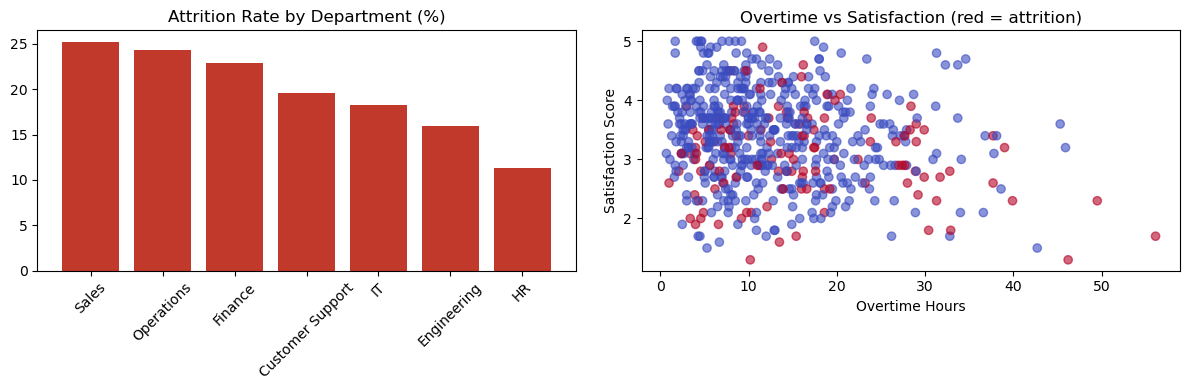

In [46]:
##EDA

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

attrition_by_dept = df.groupby('department')['attrition'].apply(lambda x: (x=='Yes').mean() * 100).sort_values(ascending=False)
axes[0].bar(attrition_by_dept.index, attrition_by_dept.values, color='#c0392b')
axes[0].set_title('Attrition Rate by Department (%)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(df['overtime_hours'], df['satisfaction_score'], c=(df['attrition']=='Yes'), cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel('Overtime Hours')
axes[1].set_ylabel('Satisfaction Score')
axes[1].set_title('Overtime vs Satisfaction (red = attrition)')

plt.tight_layout()
plt.show()

In [56]:
#Decision Support System (DSS)
def classify_risk(row):
    if row['satisfaction_score'] < 3 and row['overtime_hours'] > 15:
        return 'High Risk'
    elif row['satisfaction_score'] < 3 or row['attendance_percent'] < 90:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_level'] = df.apply(classify_risk, axis=1)
df['risk_level'].value_counts()


risk_level
Low Risk       321
Medium Risk    203
High Risk       76
Name: count, dtype: int64

In [58]:
def recommend_action(risk_level):
    mapping = {
        'High Risk': 'Immediate HR intervention (1:1 check-in, workload review)',
        'Medium Risk': 'Monitoring and engagement program',
        'Low Risk': 'Maintain and reward performance',
    }
    return mapping[risk_level]

df['recommended_action'] = df['risk_level'].apply(recommend_action)
df[['employee_id','department','satisfaction_score','overtime_hours','attendance_percent','risk_level','recommended_action']].head(10)

,employee_id,department,satisfaction_score,overtime_hours,attendance_percent,risk_level,recommended_action
0,EMP0001,Engineering,2.9,27.9,91.8,High Risk,"Immediate HR intervention (1:1 check-in, workl..."
1,EMP0002,Operations,3.7,6.7,91.6,Low Risk,Maintain and reward performance
2,EMP0003,Operations,3.1,11.6,89.5,Medium Risk,Monitoring and engagement program
3,EMP0004,HR,3.5,10.3,98.1,Low Risk,Maintain and reward performance
4,EMP0005,Operations,3.7,4.9,91.0,Low Risk,Maintain and reward performance
5,EMP0006,Customer Support,4.0,17.7,92.4,Low Risk,Maintain and reward performance
6,EMP0007,Finance,2.9,17.6,91.3,High Risk,"Immediate HR intervention (1:1 check-in, workl..."
7,EMP0008,Customer Support,3.2,3.2,97.8,Low Risk,Maintain and reward performance
8,EMP0009,Engineering,2.7,19.1,96.8,High Risk,"Immediate HR intervention (1:1 check-in, workl..."
9,EMP0010,Engineering,2.5,21.6,96.8,High Risk,"Immediate HR intervention (1:1 check-in, workl..."


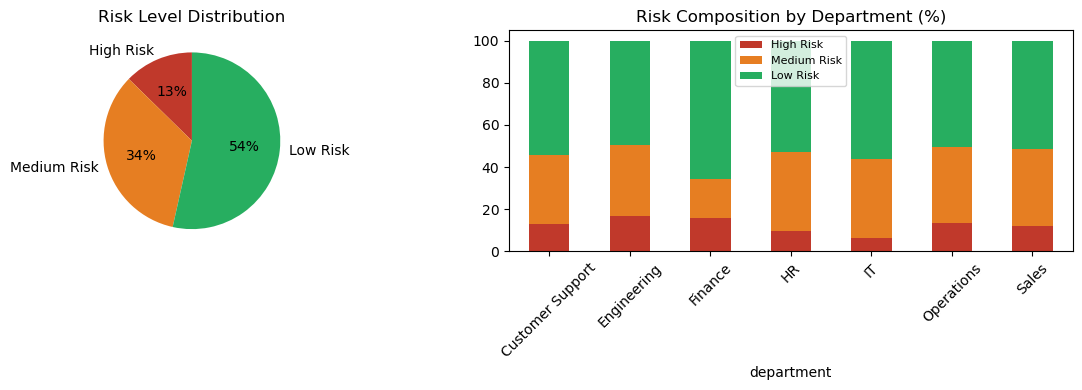

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

risk_counts = df['risk_level'].value_counts().reindex(['High Risk','Medium Risk','Low Risk'])
colors = ['#c0392b', '#e67e22', '#27ae60']
axes[0].pie(risk_counts, labels=risk_counts.index, autopct='%1.0f%%', colors=colors, startangle=90)
axes[0].set_title('Risk Level Distribution')

risk_by_dept = pd.crosstab(df['department'], df['risk_level'], normalize='index')[['High Risk','Medium Risk','Low Risk']] * 100
risk_by_dept.plot(kind='bar', stacked=True, ax=axes[1], color=colors)
axes[1].set_title('Risk Composition by Department (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [63]:
feature_cols = ['satisfaction_score', 'attendance_percent', 'overtime_hours', 'tenure_years', 'performance_rating']
X = df[feature_cols]
y = (df['attrition'] == 'Yes').astype(int)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
log_model = LogisticRegression(class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [72]:
y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 3))

              precision    recall  f1-score   support

No Attrition       0.84      0.68      0.75        96
   Attrition       0.28      0.50      0.36        24

    accuracy                           0.64       120
   macro avg       0.56      0.59      0.55       120
weighted avg       0.73      0.64      0.67       120

ROC-AUC: 0.661


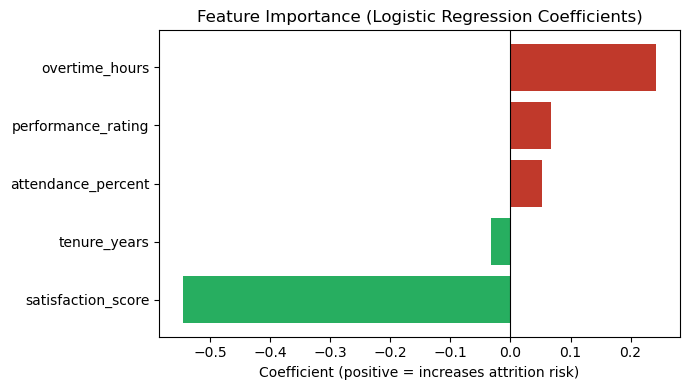

In [74]:
importance = pd.Series(log_model.coef_[0], index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors_imp = ['#c0392b' if v > 0 else '#27ae60' for v in importance.values]
ax.barh(importance.index, importance.values, color=colors_imp)
ax.set_title('Feature Importance (Logistic Regression Coefficients)')
ax.set_xlabel('Coefficient (positive = increases attrition risk)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


In [76]:
X_all_scaled = scaler.transform(df[feature_cols])
df['ml_attrition_probability'] = log_model.predict_proba(X_all_scaled)[:, 1].round(3)

high_cutoff = df['ml_attrition_probability'].quantile(0.80)
medium_cutoff = df['ml_attrition_probability'].quantile(0.50)

def ml_risk_tier(prob):
    if prob >= high_cutoff:
        return 'High Risk'
    elif prob >= medium_cutoff:
        return 'Medium Risk'
    return 'Low Risk'

df['ml_risk_level'] = df['ml_attrition_probability'].apply(ml_risk_tier)
print(f"High Risk cutoff (80th pct): {high_cutoff:.3f} | Medium Risk cutoff (50th pct): {medium_cutoff:.3f}")

comparison = pd.crosstab(df['risk_level'], df['ml_risk_level'])
comparison

High Risk cutoff (80th pct): 0.603 | Medium Risk cutoff (50th pct): 0.453


ml_risk_level,High Risk,Low Risk,Medium Risk
risk_level,,,
High Risk,69,0,7
Low Risk,10,227,84
Medium Risk,41,72,90


In [78]:
agreement_rate = (df['risk_level'] == df['ml_risk_level']).mean() * 100
print(f"Agreement between Rule-Based and ML risk levels: {agreement_rate:.1f}%")

Agreement between Rule-Based and ML risk levels: 64.3%


In [80]:
disagreements = df[df['risk_level'] != df['ml_risk_level']][
    ['employee_id','department','satisfaction_score','overtime_hours','attendance_percent','risk_level','ml_risk_level','ml_attrition_probability']
]
print(f"{len(disagreements)} employees classified differently by the two methods:")
disagreements.head(10)

214 employees classified differently by the two methods:


,employee_id,department,satisfaction_score,overtime_hours,attendance_percent,risk_level,ml_risk_level,ml_attrition_probability
6,EMP0007,Finance,2.9,17.6,91.3,High Risk,Medium Risk,0.579
11,EMP0012,Operations,2.5,13.9,91.9,Medium Risk,High Risk,0.623
12,EMP0013,Operations,1.6,13.5,95.0,Medium Risk,High Risk,0.741
15,EMP0016,HR,4.3,12.7,89.7,Medium Risk,Low Risk,0.303
20,EMP0021,Operations,3.6,24.9,100.0,Low Risk,Medium Risk,0.511
22,EMP0023,IT,3.3,7.0,89.7,Medium Risk,Low Risk,0.417
28,EMP0029,Engineering,3.6,29.0,98.3,Low Risk,Medium Risk,0.573
29,EMP0030,Engineering,2.3,9.7,100.0,Medium Risk,High Risk,0.643
30,EMP0031,Sales,4.1,3.4,89.0,Medium Risk,Low Risk,0.296
35,EMP0036,Sales,2.1,4.9,98.7,Medium Risk,High Risk,0.627


In [82]:
export_cols = ['employee_id','department','age','tenure_years','satisfaction_score',
               'attendance_percent','overtime_hours','performance_rating','attrition',
               'risk_level','recommended_action','ml_risk_level','ml_attrition_probability']

df[export_cols].to_csv('employee_risk_dashboard_data.csv', index=False)
print("Exported —", df.shape[0], "rows")

Exported — 600 rows
